ML Assignment -1

Dataset: Titanic Dataset (titanic_data_updated.csv)

Email: nizamuddinsiam2001@gmail.com

Name: Md. Nizam Uddin



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [38]:
df = pd.read_csv("titanic_data_updated.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Question 1 (10 Marks)
Load the Titanic dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [8]:
df.shape

(891, 12)

In [9]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [10]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,yes,first,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
463,464,no,second,"Milling, Mr. Jacob Christian",male,48.0,0,0,234360,13.0000,NaN,S
201,202,no,third,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.5500,NaN,S
812,813,no,second,"Slemen, Mr. Richard James",male,35.0,0,0,28206,10.5000,NaN,S
790,791,no,third,"Keane, Mr. Andrew ""Andy""",male,NaN,0,0,12460,7.7500,NaN,Q


# Question 2 (10 Marks)
Perform feature screening on the Titanic dataset by:
- Finding total missing values
- Finding duplicate rows
- Removing duplicate rows permanently

In [11]:
print(f"Total Missing Values:\n{df.isnull().sum()}\n")
print(f"Duplicate Rows: {df.duplicated().sum()}\n")
df.drop_duplicates(inplace=True)

Total Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0



# Question 3 (10 Marks)
Perform statistical profiling of the Titanic dataset and display:
- Dataset information
- Statistical summary of numerical columns

Also write 2 observations from the output.


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


1. Age,Cabin,Embarked columns contains missing values
2. There are 5 numerical columns: PassengerId,Age,Sibsp,Parch,Fare and 7 categorical columns

# Question 4 (10 Marks)
Perform univariate categorical analysis on the Survived column by:
- Creating a countplot
- Calculating percentage distribution
- Creating a pie chart

Write 2 insights from the analysis.

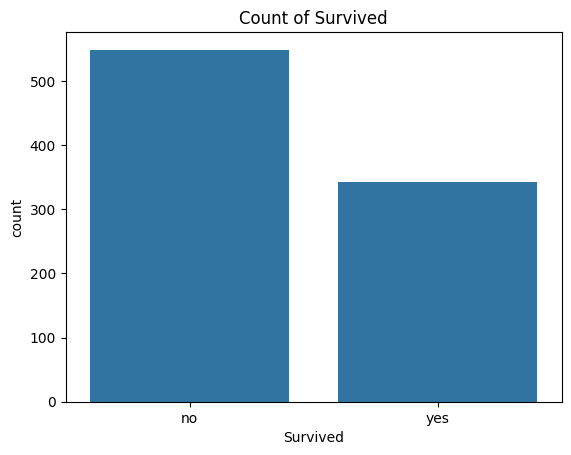

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64


In [13]:
sns.countplot(x="Survived", data=df)
plt.title("Count of Survived")
plt.show()

print((df['Survived'].value_counts() / len(df)) * 100)


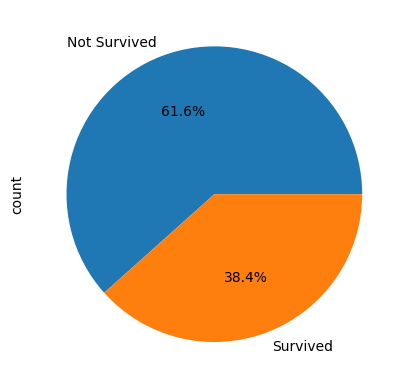

In [14]:
df["Survived"].value_counts().plot(kind="pie", autopct="%1.1f%%", labels=["Not Survived", "Survived"])
plt.show()

1. Survival rate is lower than the non-survival rate
2. Only 38% passengers survived


# Question 5 (10 Marks)
Perform univariate numerical analysis on the Age column by:
- Creating a histogram
- Creating a KDE plot

Write 2 observations from the plots.


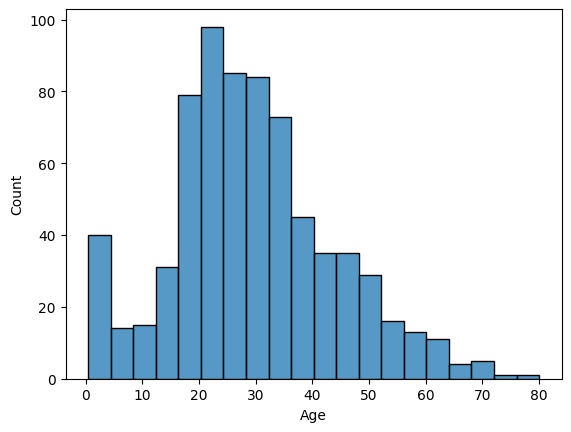

In [15]:
sns.histplot(df["Age"].dropna())
plt.show()

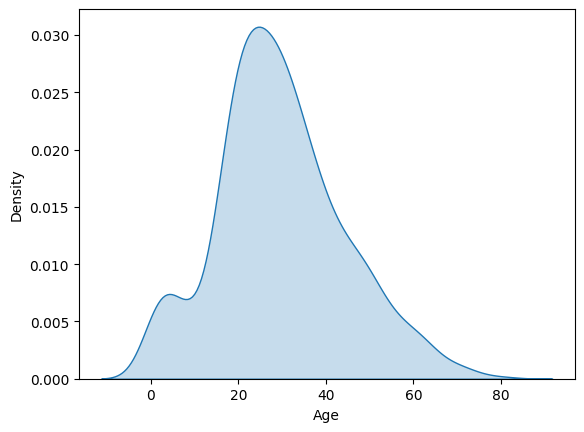

In [16]:
sns.kdeplot(df["Age"].dropna(), fill=True)
plt.show()

1. Maximum passengers were between 20 to 40 years old.
2. Elderly passengers were fewer.

# Question 6 (10 Marks)
Perform multivariate analysis between Sex and Survived using a countplot with hue.

Also calculate normalized survival ratios using groupby().

Write 2 insights from the analysis.


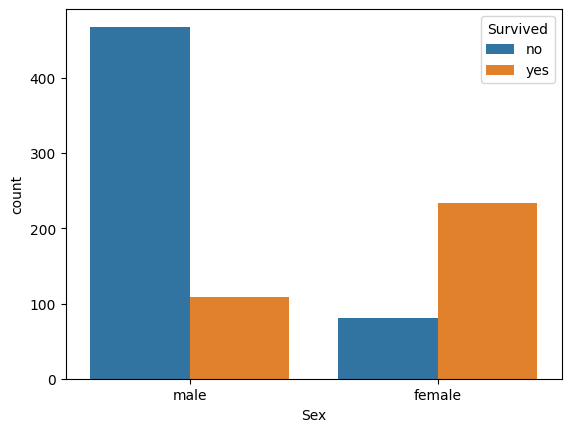

Sex     Survived
female  yes         74.203822
        no          25.796178
male    no          81.109185
        yes         18.890815
Name: proportion, dtype: float64


In [17]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

print(df.groupby("Sex")["Survived"].value_counts(normalize=True) * 100)

1. Females passengers had a higher survival rate
2. Most male passengers did not survive.

# Question 7 (10 Marks)

Create a barplot showing the relationship between Pclass and Fare.

Write 2 observations from the visualization.


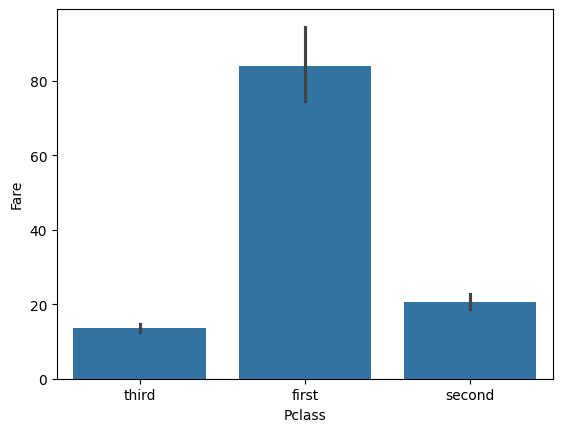

In [18]:
sns.barplot(x="Pclass", y="Fare", data=df)
plt.show()

1. First Class paid the highest fare.
2. Third Class paid the lowest fare.

# Question 8 (10 Marks)

Create a KDE plot to compare the Age distribution of survived and non-survived passengers.

Write 2 insights from the graph.


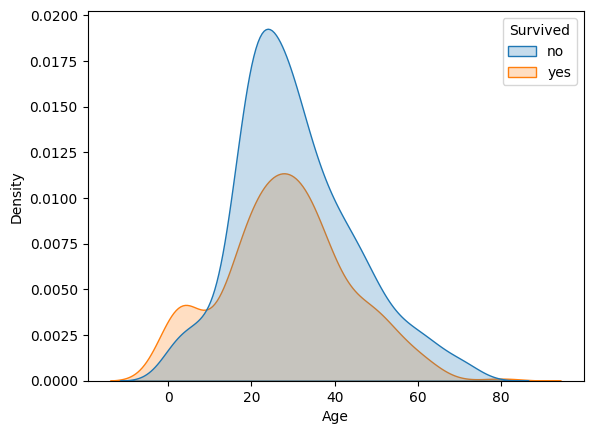

In [19]:
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True)
plt.show()

1. Younger passengers had a higher survival rate.
2. Older passengers had a lower survival rate.

# Question 9 (10 Marks)
Perform feature engineering and train-test split by:
- Dropping PassengerId, Name, and Ticket columns
- Separating features (X) and target (y)
- Splitting the dataset using test_size=0.2 and random_state=42

Display the shapes of train and test datasets.


In [39]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 8)
X_test: (179, 8)
y_train: (712,)
y_test: (179,)


# Question 10 (10 Marks)
Handle missing values in the Titanic dataset by:
- Imputing missing Age values using SimpleImputer with mean strategy
- Imputing missing Embarked values using most frequent strategy
- Imputing missing Cabin values using constant strategy with "Missing"

Finally, check whether any missing values remain.


In [52]:
age_imputer = SimpleImputer(strategy="mean")
df["Age"] = age_imputer.fit_transform(df[["Age"]]).ravel()

embarked_imputer = SimpleImputer(strategy="most_frequent")
df["Embarked"] = embarked_imputer.fit_transform(df[["Embarked"]]).ravel()

cabin_imputer = SimpleImputer(strategy="constant", fill_value="Missing")
df["Cabin"] = cabin_imputer.fit_transform(df[["Cabin"]]).ravel()

df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
